In [1]:
import os
import shutil
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, Video

from sam2.build_sam import build_sam2_video_predictor
from sam2.sam2_video_predictor import SAM2VideoPredictor

In [21]:
def extract_frames_from_mp4(mp4_path, output_dir):

    os.makedirs(output_dir, exist_ok=True)
    cap = cv2.VideoCapture(mp4_path)
    
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_name = f"{frame_idx:05d}.jpg"
        cv2.imwrite(os.path.join(output_dir, frame_name), frame)
        frame_idx += 1
        
    cap.release()
    print(f"Готово! Извлечено {frame_idx} кадров в папку {output_dir}")
    return output_dir

In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
checkpoint_path = "../data/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

In [3]:
predictor = build_sam2_video_predictor(model_cfg, checkpoint_path, device=device)

In [4]:
original_video_dir = "../data/MFT25-train/BT-001/img1/"
short_video_dir = "../data/test_video_short/"
os.makedirs(short_video_dir, exist_ok=True)

In [5]:
all_frames = sorted([p for p in os.listdir(original_video_dir) if p.endswith(('.jpg', '.png', '.jpeg'))])
frames_to_keep = 60

In [6]:
for frame_name in all_frames[:frames_to_keep]:
    src_path = os.path.join(original_video_dir, frame_name)
    dst_path = os.path.join(short_video_dir, frame_name)
    if not os.path.exists(dst_path):
        shutil.copy(src_path, dst_path)

frame_names = sorted(os.listdir(short_video_dir))

In [ ]:
clicks_coords = [[1050, 640]]
clicks_labels = [1] 

In [8]:
input_points = np.array(clicks_coords, dtype=np.float32)
input_labels = np.array(clicks_labels, dtype=np.int32)

In [10]:
first_frame_path = os.path.join(short_video_dir, frame_names[0])
first_frame = cv2.cvtColor(cv2.imread(first_frame_path), cv2.COLOR_BGR2RGB)

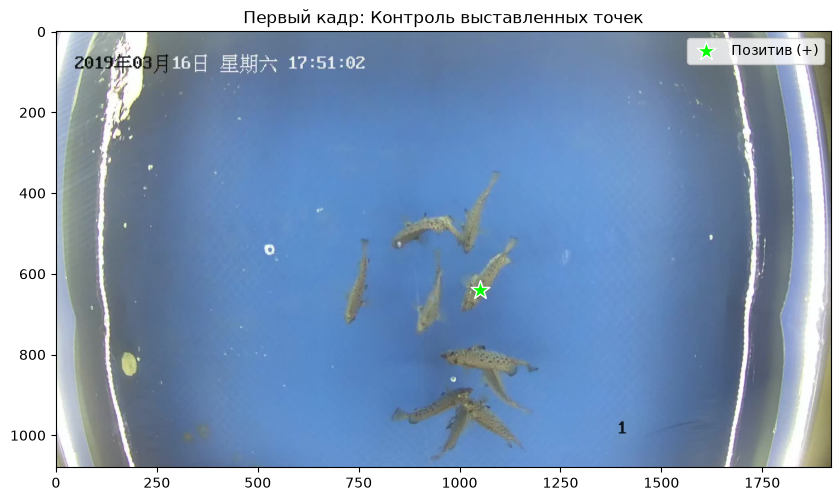

In [11]:
plt.figure(figsize=(10, 6))
plt.imshow(first_frame)

pos_points = input_points[input_labels == 1]
neg_points = input_points[input_labels == 0]

if len(pos_points) > 0:
    plt.scatter(pos_points[:, 0], pos_points[:, 1], color='lime', marker='*', s=200, label='Позитив (+)', edgecolor='white')
if len(neg_points) > 0:
    plt.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=200, label='Негатив (-)', edgecolor='white')

plt.title("Первый кадр: Контроль выставленных точек")
plt.legend()
plt.axis('on')
plt.show()

In [ ]:
inference_state = predictor.init_state(
    video_path=short_video_dir,
    offload_video_to_cpu=True, 
    offload_state_to_cpu=True  
)

frame loading (JPEG): 100%|██████████| 60/60 [00:01<00:00, 55.35it/s]


In [13]:
frame_idx = 0
obj_id = 1

In [14]:
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=frame_idx,
    obj_id=obj_id,
    points=input_points,
    labels=input_labels,
)

/Users/filimono/Documents/Inno/Interactive-fish-study-system/cv/segment-anything-2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/Users/filimono/Documents/Inno/Interactive-fish-study-system/cv/segment-anything-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


In [ ]:
video_segments = {} 
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 60/60 [00:58<00:00,  1.03it/s]

Трекинг завершен. Собираем видео с черным фоном...


In [20]:
output_dir = "../data/output/"
os.makedirs(output_dir, exist_ok=True)
output_video_path = os.path.join(output_dir, "tracked_fish_dynamic.mp4")

In [17]:
height, width, _ = first_frame.shape
fourcc = cv2.VideoWriter_fourcc(*'avc1')
video_writer = cv2.VideoWriter(output_video_path, fourcc, 30.0, (width, height))

In [18]:
for i, frame_name in enumerate(frame_names):
    frame_path = os.path.join(short_video_dir, frame_name)
    frame = cv2.imread(frame_path)
    black_bg = np.zeros_like(frame)
    
    if i in video_segments and obj_id in video_segments[i]:
        mask = video_segments[i][obj_id]
        black_bg[mask] = frame[mask] 
        
    video_writer.write(black_bg)

video_writer.release()
print(f"Готово! Видео сохранено: {output_video_path}")

Готово! Видео сохранено: ../data/output/tracked_fish_dynamic.mp4


In [19]:
display(Video(output_video_path, embed=True, width=800))